In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/raedmuhammed/dataready/FullDATA.csv")
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

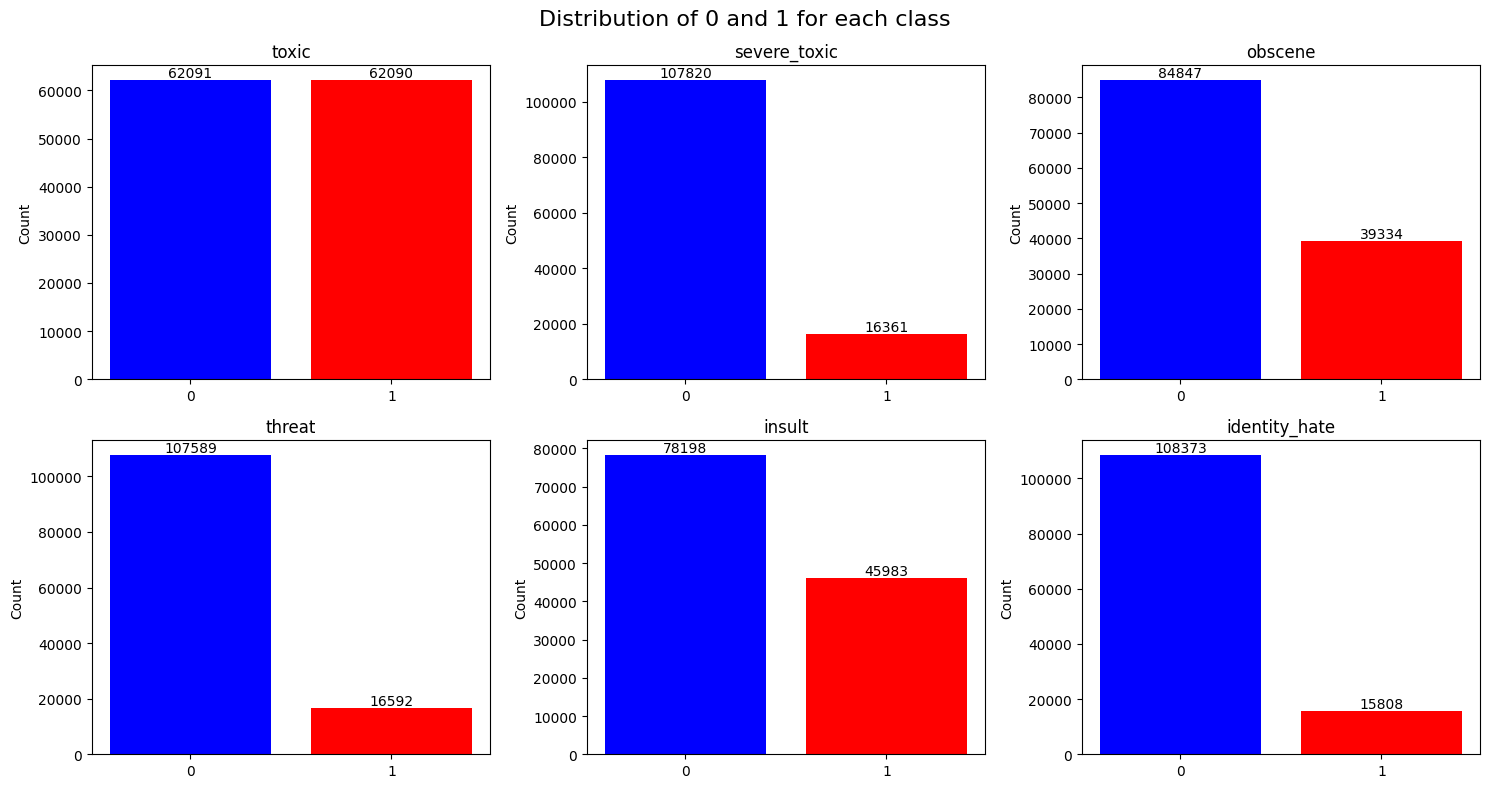

In [2]:

# grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(classes):
    # count of 0s and 1s for this class
    value_counts = df[col].value_counts().sort_index()
    axes[i].bar(['0', '1'], [value_counts.get(0, 0), value_counts.get(1, 0)],
                color=['blue', 'red'])
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
    # show the count value above each bar
    for j, v in enumerate([value_counts.get(0, 0), value_counts.get(1, 0)]):
        axes[i].text(j, v, str(v), ha='center', va='bottom')

plt.suptitle('Distribution of 0 and 1 for each class', fontsize=16)
plt.tight_layout()
plt.show()

In [3]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re 

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

#Clean data
def preprocess_text(text):
   
    text = str(text)
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]"," ",text )
    text = re.sub(r"\s+"," ",text).strip()
    words = word_tokenize(text)
    
    # Remove stopwords and apply lemmatization
    clean_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(clean_words)
    words = word_tokenize(text)

    # lemmatize and remove stopwords 
    clean_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    clean_text = " ".join(clean_words)

    return clean_text

In [4]:
df["clean_text"] = df["comment_text"].apply(preprocess_text)

In [5]:
from skmultilearn.model_selection import IterativeStratification

# multi-label stratified split (80% train,15% val,15% test )

label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


df = df.drop_duplicates(subset="clean_text").reset_index(drop=True)
y = df[label_cols].values.astype(int)
X_idx = np.zeros((len(df), 1))       


strat1 = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[0.30, 0.70])
train_idx, rest_idx = next(strat1.split(X_idx, y))


y_rest = y[rest_idx]
strat2 = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[0.50, 0.50])
val_rel, test_rel = next(strat2.split(np.zeros((len(rest_idx), 1)), y_rest))

val_idx  = rest_idx[val_rel]      
test_idx = rest_idx[test_rel]


train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

X_train_text, y_train = train_df["clean_text"], train_df[label_cols].values
X_val_text,   y_val   = val_df["clean_text"],   val_df[label_cols].values
X_test_text,  y_test  = test_df["clean_text"],  test_df[label_cols].values


n = len(df)
for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: {len(part)} ({len(part)/n:.1%})")

dist = pd.DataFrame({
    "train": train_df[label_cols].mean(),
    "val":   val_df[label_cols].mean(),
    "test":  test_df[label_cols].mean(),
})
print(dist.round(4))


assert not set(train_df.clean_text) & set(val_df.clean_text)
assert not set(train_df.clean_text) & set(test_df.clean_text)
assert not set(val_df.clean_text) & set(test_df.clean_text)

train: 85715 (70.0%)
val: 18367 (15.0%)
test: 18368 (15.0%)
                train     val    test
toxic          0.5021  0.5021  0.5021
severe_toxic   0.1136  0.1781  0.1798
obscene        0.3206  0.3154  0.3154
threat         0.1333  0.1375  0.1376
insult         0.3767  0.3642  0.3630
identity_hate  0.0993  0.1961  0.1960


In [6]:
from tensorflow.keras.layers import TextVectorization

vocab_size = 30000
sequence_length = 50

vectorize_layer = TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length
)

# Build vocabulary from training text only
print("Building vocabulary...")
vectorize_layer.adapt(X_train_text.to_numpy())
print("Vocabulary built! size =", len(vectorize_layer.get_vocabulary()))

# Convert text to padded integer sequences
X_train_seq = vectorize_layer(X_train_text.to_numpy())
X_val_seq   = vectorize_layer(X_val_text.to_numpy())
X_test_seq  = vectorize_layer(X_test_text.to_numpy())

print("X_train_seq shape:", X_train_seq.shape)
print("X_val_seq shape:  ", X_val_seq.shape)
print("X_test_seq shape: ", X_test_seq.shape)


# Convert to NumPy with correct data types
X_train_seq = np.asarray(X_train_seq).astype(np.int32)
X_val_seq   = np.asarray(X_val_seq).astype(np.int32)
X_test_seq  = np.asarray(X_test_seq).astype(np.int32)

y_train = np.asarray(y_train).astype(np.float32)
y_val   = np.asarray(y_val).astype(np.float32)
y_test  = np.asarray(y_test).astype(np.float32)


# Save datasets
np.savez_compressed(
    "datasets.npz",
    X_train_seq=X_train_seq,
    y_train=y_train,
    X_val_seq=X_val_seq,
    y_val=y_val,
    X_test_seq=X_test_seq,
    y_test=y_test
)

print("Datasets saved successfully!")

2026-10-03 00:42:57.800234: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Building vocabulary...
Vocabulary built! size = 30000
X_train_seq shape: (85715, 50)
X_val_seq shape:   (18367, 50)
X_test_seq shape:  (18368, 50)
Datasets saved successfully!


In [8]:
import json
json.dump({
    "vocabulary": vectorize_layer.get_vocabulary(),
    "sequence_length": 50,
    "label_cols": label_cols,
    "threshold": 0.5,        
}, open("/kaggle/working/config.json", "w"))